<a href="https://colab.research.google.com/github/Shakiba-Fatima/Project/blob/main/practice2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Cell 1 — Install Libraries


In [1]:
!pip install xgboost scikit-learn imbalanced-learn pandas matplotlib seaborn -q

✅ Cell 2 — Generate Dataset


In [20]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000
fraud_ratio = 0.05

n_fraud = int(n * fraud_ratio)
n_normal = n - n_fraud

normal = pd.DataFrame({
    'transaction_amount':   np.random.normal(100, 50, n_normal).clip(5, 500),
    'transaction_hour':     np.random.randint(8, 22, n_normal),
    'day_of_week':          np.random.randint(0, 7, n_normal),
    'payment_channel':      np.random.choice(['online','POS','ATM'], n_normal, p=[0.4,0.4,0.2]),
    'device_type':          np.random.choice(['mobile','desktop','card'], n_normal, p=[0.5,0.3,0.2]),
    'customer_age':         np.random.randint(18, 70, n_normal),
    'account_age_days':     np.random.randint(180, 3600, n_normal),
    'transaction_count_7d': np.random.randint(1, 15, n_normal),
    'avg_amount_7d':        np.random.normal(95, 40, n_normal).clip(5, 400),
    'amount_deviation':     np.random.normal(5, 20, n_normal).clip(0, 100),
    'foreign_transaction':  np.random.choice([0, 1], n_normal, p=[0.95, 0.05]),
    'failed_attempts':      np.random.choice([0, 1, 2], n_normal, p=[0.90, 0.08, 0.02]),
    'is_fraud':             0
})

fraud = pd.DataFrame({
    'transaction_amount':   np.random.normal(400, 100, n_fraud).clip(200, 1000),
    'transaction_hour':     np.random.randint(0, 6, n_fraud),
    'day_of_week':          np.random.randint(0, 7, n_fraud),
    'payment_channel':      np.random.choice(['online','POS','ATM'], n_fraud, p=[0.7,0.1,0.2]),
    'device_type':          np.random.choice(['mobile','desktop','card'], n_fraud, p=[0.6,0.3,0.1]),
    'customer_age':         np.random.randint(18, 70, n_fraud),
    'account_age_days':     np.random.randint(1, 180, n_fraud),
    'transaction_count_7d': np.random.randint(10, 50, n_fraud),
    'avg_amount_7d':        np.random.normal(60, 30, n_fraud).clip(5, 200),
    'amount_deviation':     np.random.normal(300, 80, n_fraud).clip(100, 600),
    'foreign_transaction':  np.random.choice([0, 1], n_fraud, p=[0.3, 0.7]),
    'failed_attempts':      np.random.choice([0, 1, 2], n_fraud, p=[0.3, 0.3, 0.4]),
    'is_fraud':             1
})

df = pd.concat([normal, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Fraud cases:", df['is_fraud'].sum())
print("Non-fraud cases:", (df['is_fraud']==0).sum())
print("Fraud %:", round(df['is_fraud'].mean()*100, 2), "%")
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (10000, 13)
Fraud cases: 500
Non-fraud cases: 9500
Fraud %: 5.0 %

First 5 rows:
   transaction_amount  transaction_hour  day_of_week payment_channel  \
0          231.894088                12            6             POS   
1           48.146696                10            3          online   
2           82.534160                19            6             POS   
3          100.080952                15            6             POS   
4          153.716650                18            3             POS   

  device_type  customer_age  account_age_days  transaction_count_7d  \
0     desktop            39              1344                     5   
1      mobile            18              1590                    11   
2      mobile            29               845                    12   
3     desktop            49              1853                    11   
4     desktop            51              1050                     8   

   avg_amount_7d  amount_deviation  foreign_

✅ Cell 3 — Encode Categorical Columns


In [3]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['payment_channel', 'device_type']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
print(df.head())

Encoding done!
   transaction_amount  transaction_hour  day_of_week  payment_channel  \
0          231.894088                12            6                1   
1           48.146696                10            3                2   
2           82.534160                19            6                1   
3          100.080952                15            6                1   
4          153.716650                18            3                1   

   device_type  customer_age  account_age_days  transaction_count_7d  \
0            1            39              1344                     5   
1            2            18              1590                    11   
2            2            29               845                    12   
3            1            49              1853                    11   
4            1            51              1050                     8   

   avg_amount_7d  amount_deviation  foreign_transaction  failed_attempts  \
0      72.770734         40.071580   

✅ Cell 4 — Train Test Split


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train fraud cases:", y_train.sum())
print("Test fraud cases:", y_test.sum())

Train size: (8000, 12)
Test size: (2000, 12)
Train fraud cases: 400
Test fraud cases: 100


✅ Cell 5 — SMOTE + Scale Pos Weight


In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scale_pos_weight = len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1])
print("After SMOTE - Non-Fraud:", (y_train_sm==0).sum())
print("After SMOTE - Fraud:", y_train_sm.sum())
print("Scale pos weight:", scale_pos_weight)

After SMOTE - Non-Fraud: 7600
After SMOTE - Fraud: 7600
Scale pos weight: 1.0


✅ Cell 6 — Train XGBoost Model


In [6]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_sm, y_train_sm)
print("Model training complete!")

Model training complete!


✅ Cell 7 — Predict with Threshold


In [7]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print("Predicted fraud cases:", y_pred.sum())
print("Actual fraud cases:", y_test.sum())

Predicted fraud cases: 100
Actual fraud cases: 100


✅ Cell 8 — Evaluation Metrics


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1900    0]
 [   0  100]]
ROC-AUC: 1.0


✅ Cell 9 — Feature Importance Plot


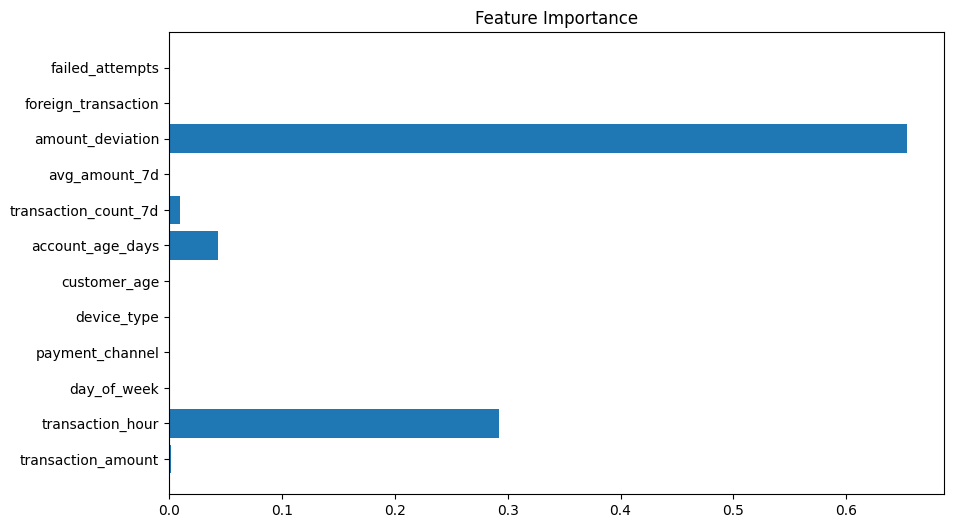

In [9]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

✅ Cell 10 — Confusion Matrix Heatmap


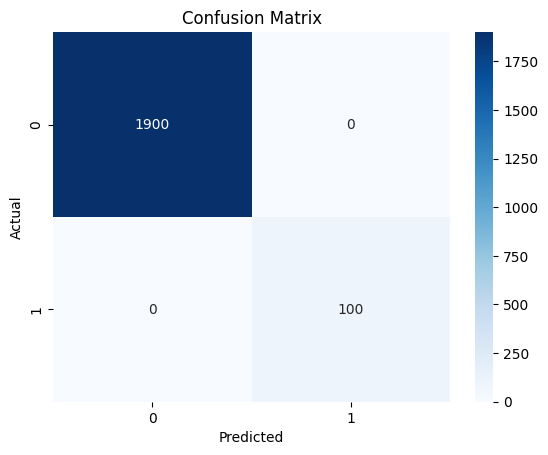

In [10]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

✅ Cell 11 — Fraud vs Non-Fraud Distribution


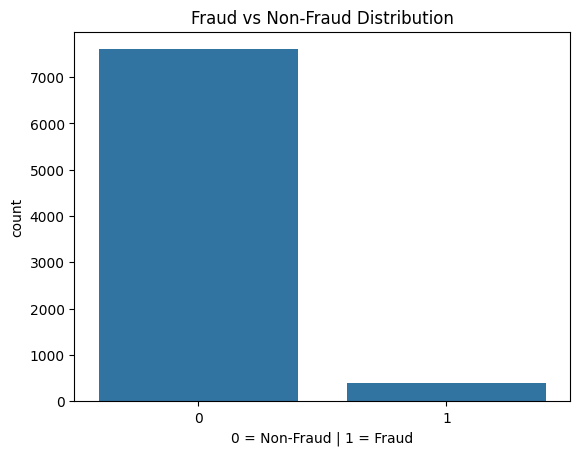

In [11]:
sns.countplot(x=y_train)
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("0 = Non-Fraud | 1 = Fraud")
plt.show()

✅ Cell 12 — Transaction Amount vs Fraud


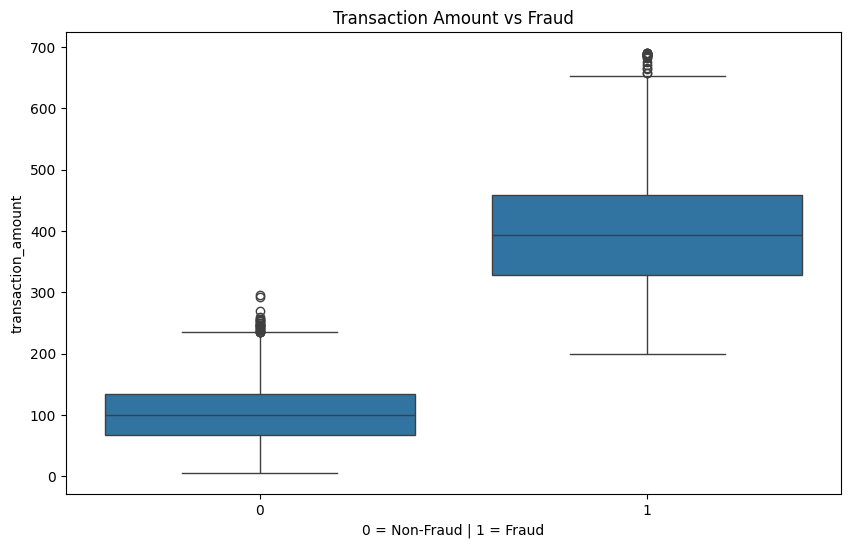

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x=y_train_sm, y=X_train_sm['transaction_amount'])
plt.title("Transaction Amount vs Fraud")
plt.xlabel("0 = Non-Fraud | 1 = Fraud")
plt.show()

✅ Cell 13 — Correlation Heatmap


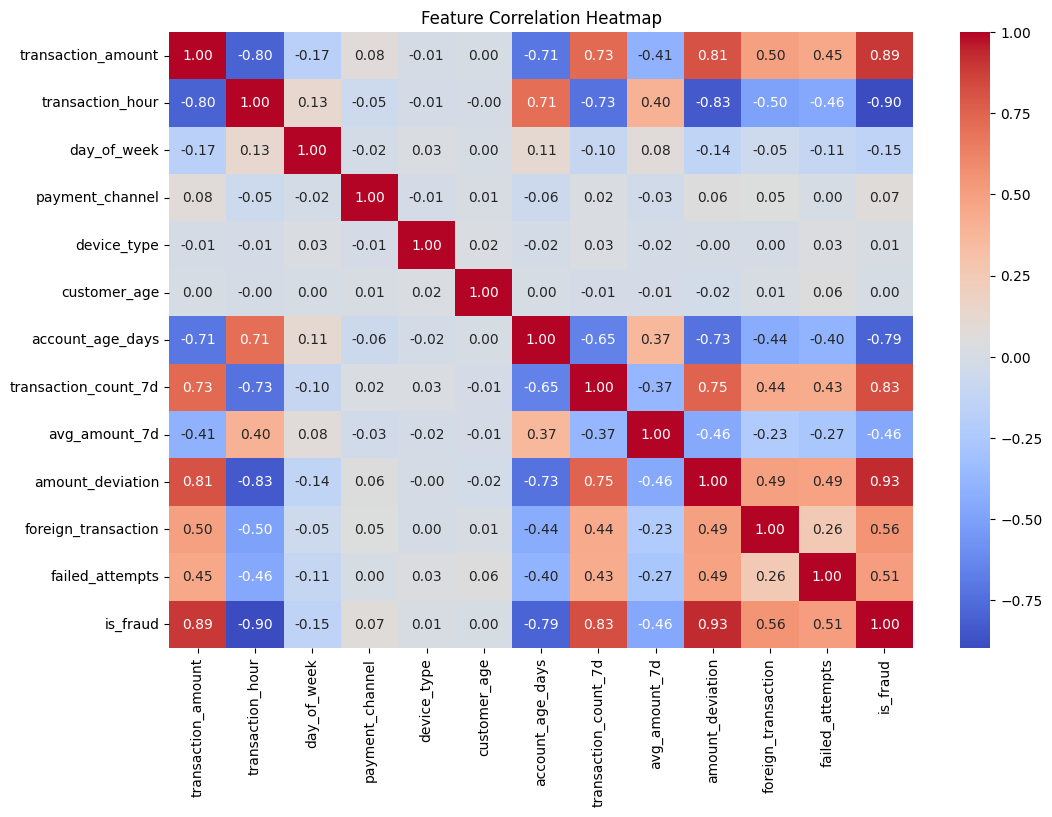

In [13]:
plt.figure(figsize=(12,8))
train_df = X_train_sm.copy()
train_df['is_fraud'] = y_train_sm.values
sns.heatmap(train_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

✅ Cell 14 — Model Comparison (Recall)


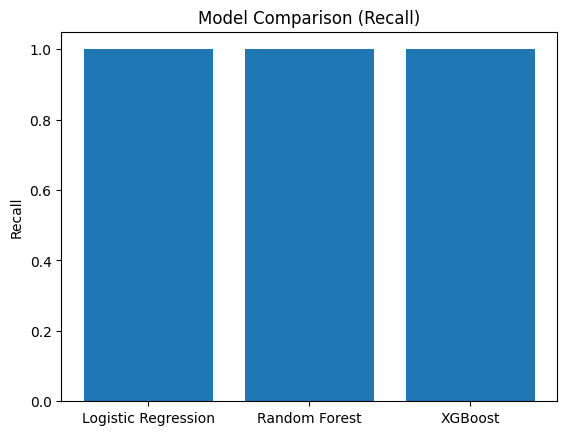

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": model
}

results = {}

for name, m in models.items():
    if name != "XGBoost":
        m.fit(X_train_sm, y_train_sm)
        y_pred_temp = m.predict(X_test)
    else:
        y_pred_temp = y_pred
    results[name] = recall_score(y_test, y_pred_temp)

plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Recall)")
plt.ylabel("Recall")
plt.show()

✅ Cell 15 — ROC Curve


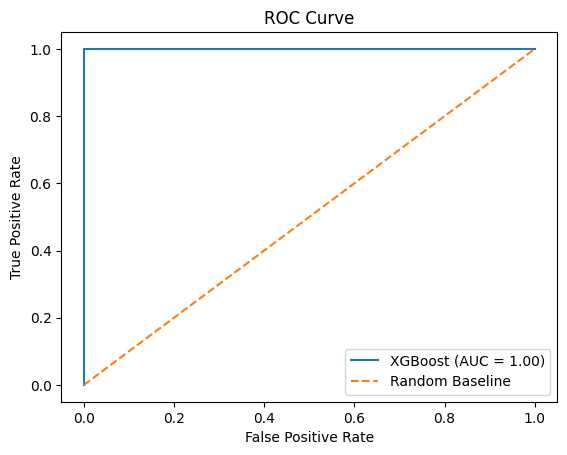

In [15]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

✅ Cell 16 — Precision-Recall Curve


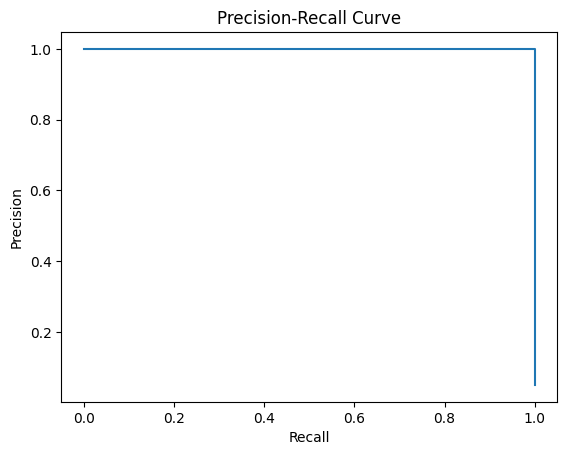

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

✅ Cell 17 — Final Feature Importance


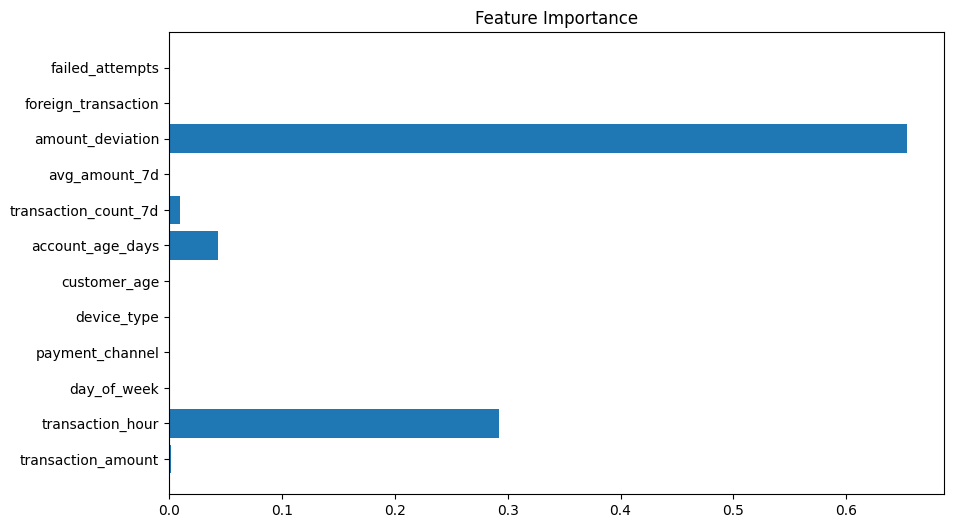

In [17]:
importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()